<a href="https://colab.research.google.com/github/smdarshad000-lab/data-science-concepts/blob/main/Exp9_Arshad_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment-9: Static Pattern Recognition & Dynamic Hand Gesture Recognition
**MCA-AIML | Pattern Recognition Lab | UPES, Dehradun**

**Aim:** To design and implement a neural network model for:
- **Part A:** Static pattern recognition (MNIST handwritten digits — CNN)
- **Part B:** Dynamic hand gesture recognition (CNN + LSTM)

---

# 🔷 PART A: Static Pattern Recognition — MNIST

## Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Load MNIST Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)


## Step 3: Preprocess Data
- Normalise pixels to [0,1]
- Reshape to add channel dimension
- One-hot encode labels

In [ ]:
# Normalise
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Reshape: (N,28,28) -> (N,28,28,1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# Integer labels for metrics
y_train_int = y_train.flatten()
y_test_int  = y_test.flatten()

# One-hot encode
y_train_oh = to_categorical(y_train_int, 10)
y_test_oh  = to_categorical(y_test_int,  10)

print(f'X_train: {X_train.shape}, y_train_oh: {y_train_oh.shape}')

X_train: (60000, 28, 28, 1), y_train_oh: (60000, 10)


## Step 4: Visualise Sample MNIST Images

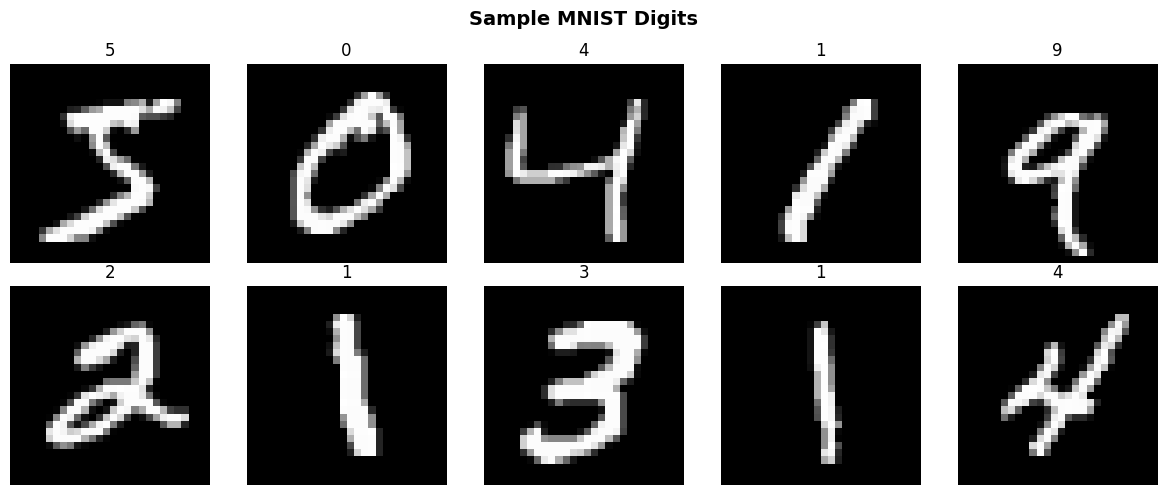

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(str(y_train_int[i]), fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Build CNN Model for Static Recognition

In [ ]:
def build_static_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='Static_CNN')
    return model

static_model = build_static_cnn()
static_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Static_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Static CNN

In [ ]:
static_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Static CNN compiled.')

Static CNN compiled.


## Step 7: Train the Static CNN

In [ ]:
static_history = static_model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8790 - loss: 0.3862 - val_accuracy: 0.9749 - val_loss: 0.0833
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9601 - loss: 0.1292 - val_accuracy: 0.9831 - val_loss: 0.0557
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9719 - loss: 0.0939 - val_accuracy: 0.9860 - val_loss: 0.0459
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9761 - loss: 0.0777 - val_accuracy: 0.9870 - val_loss: 0.0448
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9793 - loss: 0.0688 - val_accuracy: 0.9889 - val_loss: 0.0361
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9809 - loss: 0.0629 - val_accuracy: 0.9897 - val_loss: 0.0341
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9896 - val_loss: 0.0337
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9833 - loss: 0.0525 - val_accuracy: 

## Step 8: Plot Training Curves — Static CNN

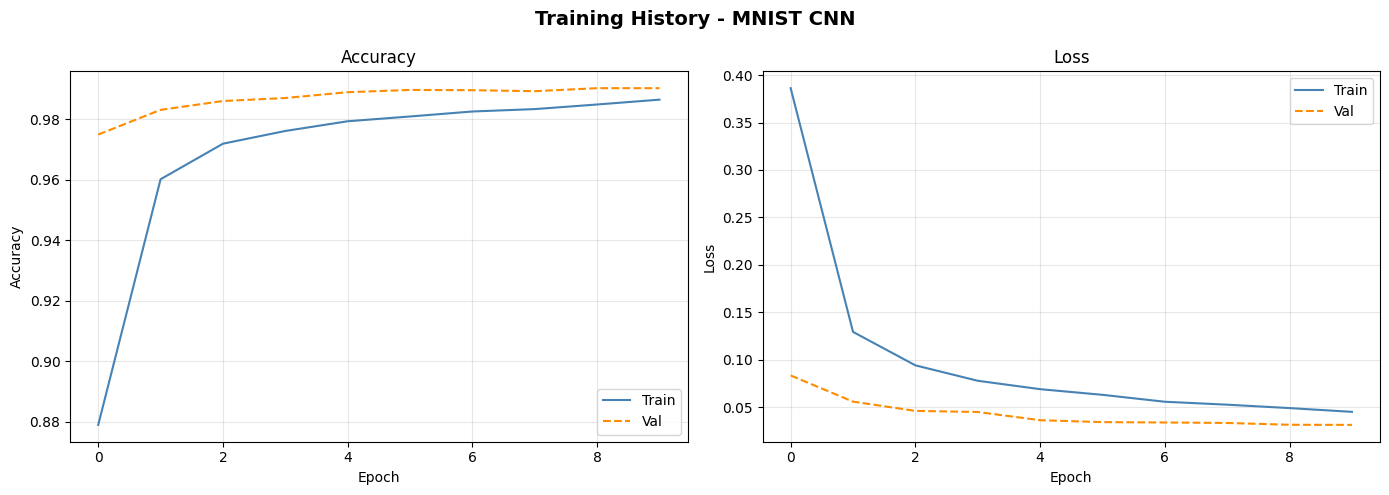

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History - MNIST CNN', fontsize=14, fontweight='bold')

ax1.plot(static_history.history['accuracy'],     label='Train', color='steelblue')
ax1.plot(static_history.history['val_accuracy'], label='Val',   color='darkorange', linestyle='--')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(static_history.history['loss'],     label='Train', color='steelblue')
ax2.plot(static_history.history['val_loss'], label='Val',   color='darkorange', linestyle='--')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Evaluate Static CNN

In [ ]:
test_loss, test_acc = static_model.evaluate(X_test, y_test_oh, verbose=0)
print(f'MNIST Test Loss     : {test_loss:.4f}')
print(f'MNIST Test Accuracy : {test_acc*100:.2f}%')

MNIST Test Loss     : 0.0233
MNIST Test Accuracy : 99.27%


## Step 10: Confusion Matrix — Static CNN

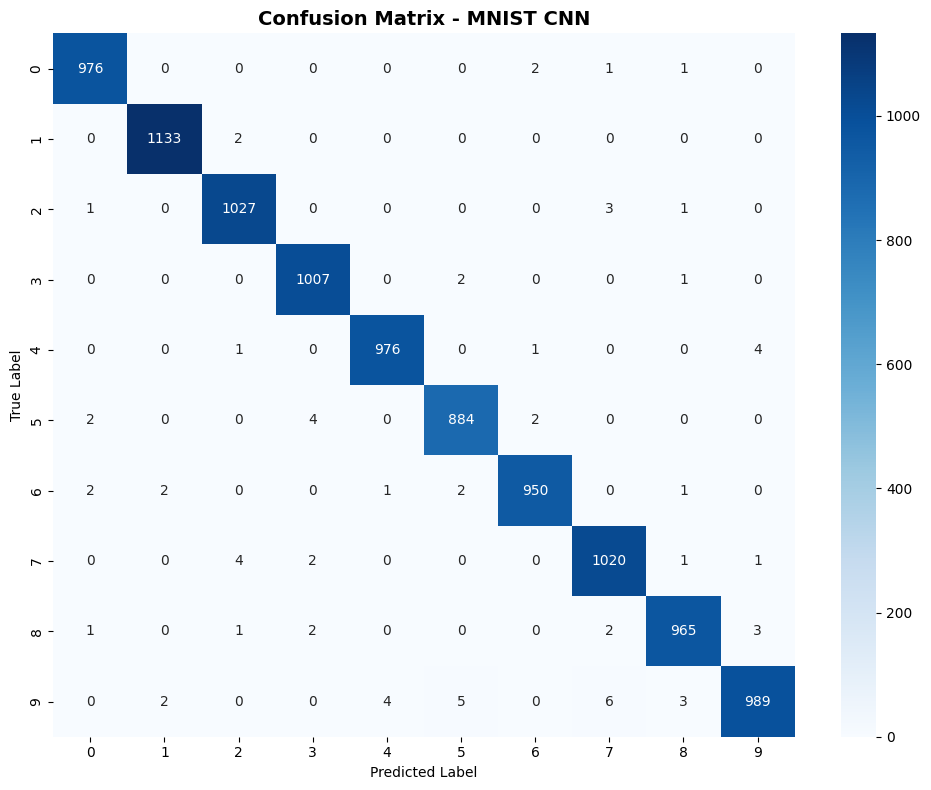

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
y_pred_oh  = static_model.predict(X_test, verbose=0)
y_pred_int = np.argmax(y_pred_oh, axis=1)

cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST CNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test_int, y_pred_int))

## Step 11: Test on Sample Inputs — Static CNN

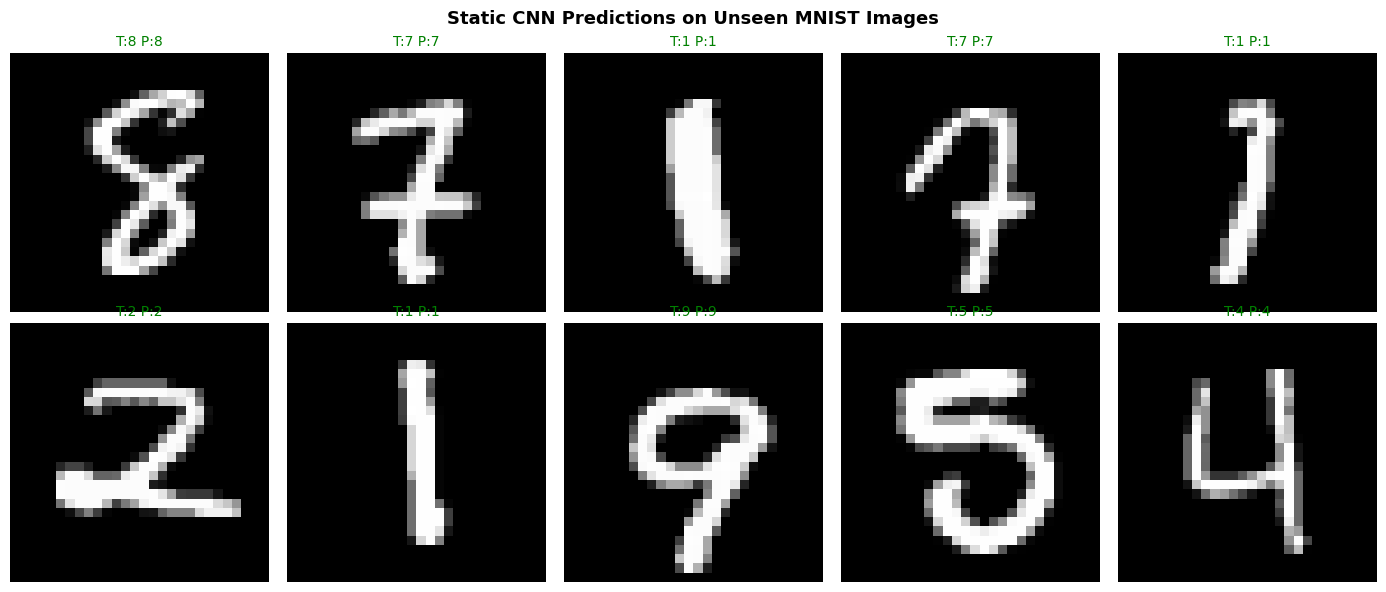

In [ ]:
np.random.seed(0)
indices  = np.random.choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Static CNN Predictions on Unseen MNIST Images',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[indices[i]].squeeze(), cmap='gray')
    true = y_test_int[indices[i]]
    pred = y_pred_int[indices[i]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'T:{true} P:{pred}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('mnist_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔶 PART B: Dynamic Hand Gesture Recognition — CNN + LSTM

We use the **20BN-Jester** style simulation with synthetic gesture data.
For a real webcam version, see the OpenCV section at the bottom.

**Pipeline:** Frames → CNN (spatial features per frame) → LSTM (temporal modelling) → Gesture Class

## Step 12: Install / Import Additional Libraries

In [ ]:
import cv2
import os, random
from tensorflow.keras.layers import (
    TimeDistributed, LSTM, GlobalAveragePooling2D, Input
)
from tensorflow.keras.models import Model
print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Step 13: Create Synthetic Gesture Dataset

Since a real gesture dataset needs webcam recording, we create a **synthetic dataset**
to demonstrate the full CNN-LSTM pipeline.

Each sample = sequence of `T=10` frames (64×64 grayscale), 5 gesture classes.

In [ ]:
# ── Synthetic dataset parameters ────────────────────────────────────
T           = 10     # frames per gesture clip
IMG_H       = 64
IMG_W       = 64
N_CLASSES   = 5      # gesture classes
N_TRAIN     = 400    # training samples
N_TEST      = 100    # test samples
GESTURE_NAMES = ['Swipe Left','Swipe Right','Swipe Up','Swipe Down','Circle']

def make_gesture_sequence(cls, T, H, W):
    """Synthetic gesture: each class has a unique moving bright region."""
    frames = []
    for t in range(T):
        frame = np.zeros((H, W), dtype=np.float32)
        # Each class → blob moves in a different direction
        offsets = [
            (H//2,          int(t * W/(T-1))),          # swipe left→right
            (H//2,          int(W - t * W/(T-1))),      # swipe right→left
            (int(t * H/(T-1)), W//2),                   # swipe top→bottom
            (int(H - t * H/(T-1)), W//2),               # swipe bottom→top
            (int(H//2 + 20*np.sin(2*np.pi*t/T)),        # circle
             int(W//2 + 20*np.cos(2*np.pi*t/T))),
        ]
        cy, cx = offsets[cls]
        cy = np.clip(cy, 5, H-5)
        cx = np.clip(cx, 5, W-5)
        frame[cy-5:cy+5, cx-5:cx+5] = 1.0
        # Add noise
        frame += np.random.normal(0, 0.05, (H, W)).astype(np.float32)
        frame = np.clip(frame, 0, 1)
        frames.append(frame)
    return np.stack(frames, axis=0)   # (T, H, W)

def make_dataset(n_samples, T, H, W, n_classes):
    X, y = [], []
    for _ in range(n_samples):
        cls = random.randint(0, n_classes-1)
        seq = make_gesture_sequence(cls, T, H, W)
        X.append(seq)
        y.append(cls)
    X = np.array(X)[..., np.newaxis]   # (N, T, H, W, 1)
    y = np.array(y)
    return X, y

np.random.seed(42); random.seed(42)
X_gest_train, y_gest_train = make_dataset(N_TRAIN, T, IMG_H, IMG_W, N_CLASSES)
X_gest_test,  y_gest_test  = make_dataset(N_TEST,  T, IMG_H, IMG_W, N_CLASSES)

y_gest_train_oh = to_categorical(y_gest_train, N_CLASSES)
y_gest_test_oh  = to_categorical(y_gest_test,  N_CLASSES)

print(f'Train: {X_gest_train.shape}  Test: {X_gest_test.shape}')

Train: (400, 10, 64, 64, 1)  Test: (100, 10, 64, 64, 1)


## Step 14: Visualise Sample Gesture Sequences

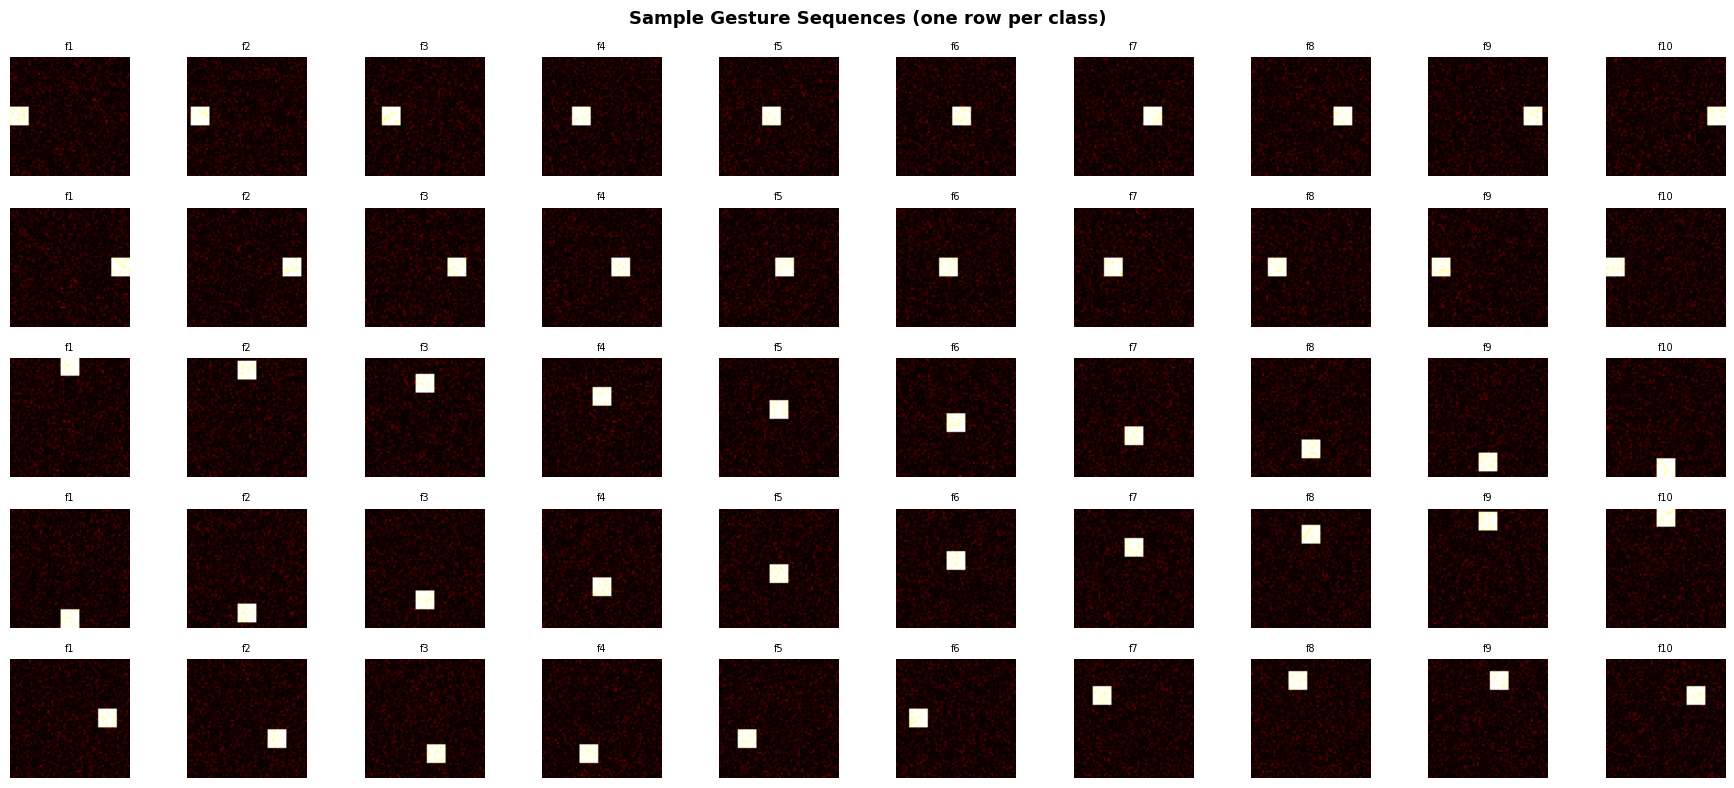

In [ ]:
fig, axes = plt.subplots(N_CLASSES, T, figsize=(18, 8))
fig.suptitle('Sample Gesture Sequences (one row per class)',
             fontsize=13, fontweight='bold')

for cls in range(N_CLASSES):
    seq = make_gesture_sequence(cls, T, IMG_H, IMG_W)
    for t in range(T):
        axes[cls, t].imshow(seq[t], cmap='hot')
        axes[cls, t].axis('off')
        if t == 0:
            axes[cls, t].set_ylabel(GESTURE_NAMES[cls], fontsize=8, rotation=0,
                                    labelpad=60, va='center')
        axes[cls, t].set_title(f'f{t+1}', fontsize=7)

plt.tight_layout()
plt.savefig('gesture_sequences.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15: Build CNN-LSTM Model

In [ ]:
def build_cnn_lstm(T, H, W, n_classes):
    # ── CNN backbone (applied to each frame via TimeDistributed) ──
    frame_input = Input(shape=(H, W, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(frame_input)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = GlobalAveragePooling2D()(x)   # (64,)
    cnn_backbone = Model(frame_input, x, name='CNN_Backbone')

    # ── Full CNN-LSTM model ──
    seq_input = Input(shape=(T, H, W, 1), name='sequence_input')
    features  = TimeDistributed(cnn_backbone)(seq_input)  # (T, 64)
    x         = LSTM(128, return_sequences=False)(features)
    x         = layers.Dropout(0.5)(x)
    output    = layers.Dense(n_classes, activation='softmax')(x)

    model = Model(seq_input, output, name='CNN_LSTM')
    return model

gesture_model = build_cnn_lstm(T, IMG_H, IMG_W, N_CLASSES)
gesture_model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 10, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 64)         │        18,816 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,277 (462.02 KB)

 Trainable params: 118,277 (462.02 KB)

 Non-trainable params: 0 (0.00 B)

## Step 16: Compile CNN-LSTM

In [ ]:
gesture_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('CNN-LSTM model compiled.')

CNN-LSTM model compiled.


## Step 17: Train CNN-LSTM

In [ ]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

gesture_history = gesture_model.fit(
    X_gest_train, y_gest_train_oh,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1688 - loss: 1.6110 - val_accuracy: 0.1875 - val_loss: 1.6078 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2344 - loss: 1.6044 - val_accuracy: 0.2375 - val_loss: 1.6071 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2188 - loss: 1.6077 - val_accuracy: 0.2375 - val_loss: 1.6044 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2406 - loss: 1.5978 - val_accuracy: 0.2375 - val_loss: 1.6000 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2281 - loss: 1.5933 - val_accuracy: 0.2375 - val_loss: 1.5839 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2625 - loss: 1.5155 - val_accuracy: 0.5250 - val_loss: 1.2821 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4406 - loss: 1.1798 - val_acc

## Step 18: Plot Training Curves — CNN-LSTM

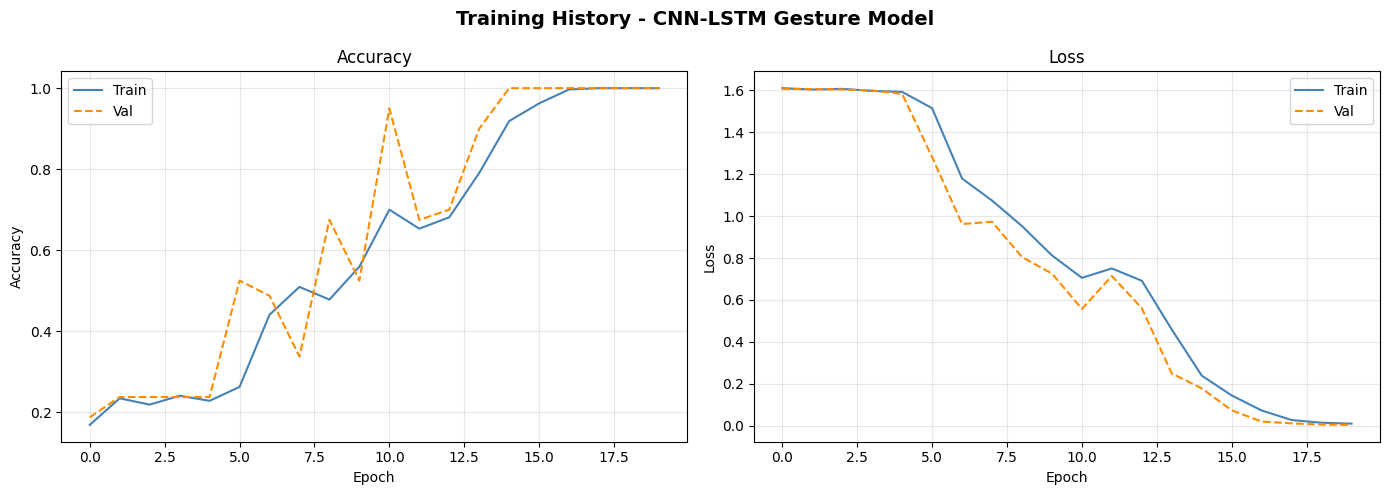

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History - CNN-LSTM Gesture Model',
             fontsize=14, fontweight='bold')

ax1.plot(gesture_history.history['accuracy'],     label='Train', color='steelblue')
ax1.plot(gesture_history.history['val_accuracy'], label='Val',   color='darkorange', linestyle='--')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(gesture_history.history['loss'],     label='Train', color='steelblue')
ax2.plot(gesture_history.history['val_loss'], label='Val',   color='darkorange', linestyle='--')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gesture_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 19: Evaluate CNN-LSTM

In [ ]:
g_loss, g_acc = gesture_model.evaluate(X_gest_test, y_gest_test_oh, verbose=0)
print(f'Gesture Test Loss     : {g_loss:.4f}')
print(f'Gesture Test Accuracy : {g_acc*100:.2f}%')

Gesture Test Loss     : 0.0042
Gesture Test Accuracy : 100.00%


## Step 20: Confusion Matrix — CNN-LSTM

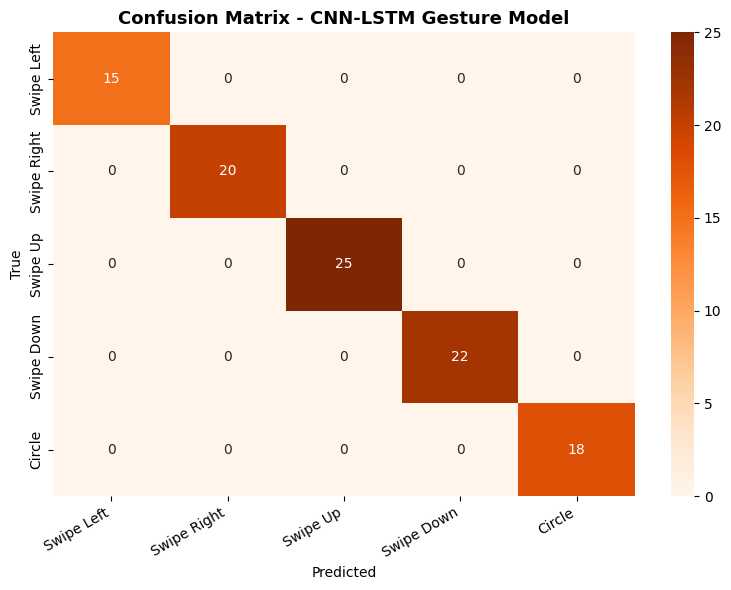

              precision    recall  f1-score   support

  Swipe Left       1.00      1.00      1.00        15
 Swipe Right       1.00      1.00      1.00        20
    Swipe Up       1.00      1.00      1.00        25
  Swipe Down       1.00      1.00      1.00        22
      Circle       1.00      1.00      1.00        18

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
y_gest_pred = np.argmax(gesture_model.predict(X_gest_test, verbose=0), axis=1)

cm_g = confusion_matrix(y_gest_test, y_gest_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Oranges',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)
plt.title('Confusion Matrix - CNN-LSTM Gesture Model',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('gesture_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_gest_test, y_gest_pred,
                             target_names=GESTURE_NAMES))

## Step 21: Predict on Sample Gesture Sequences

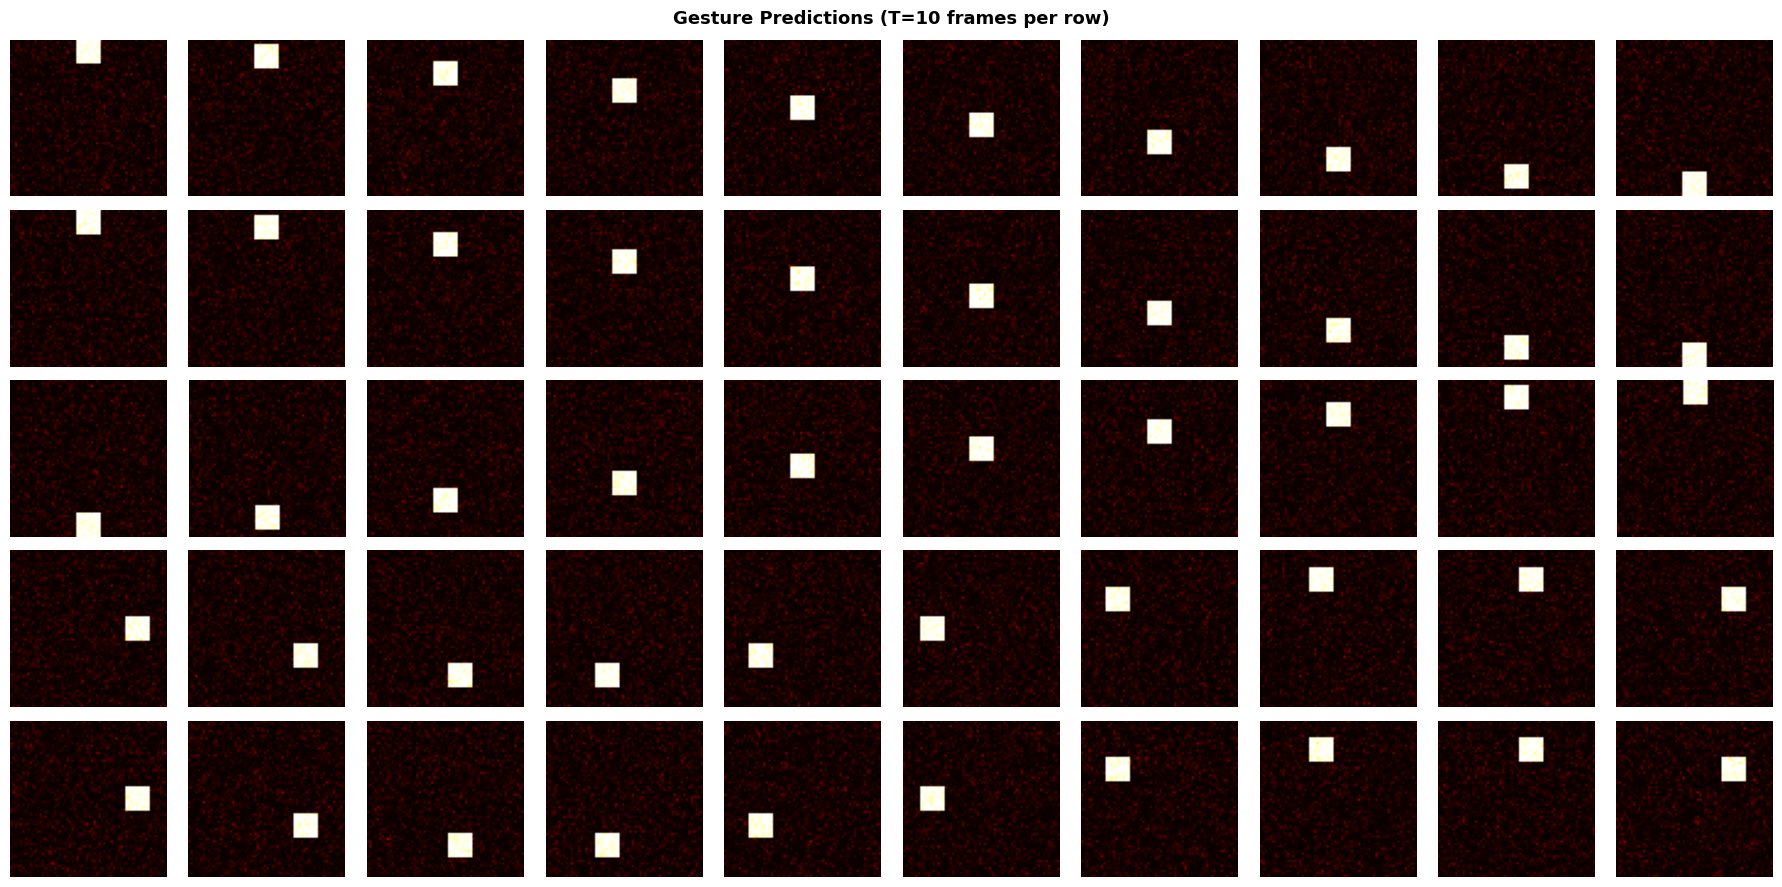

In [ ]:
np.random.seed(7)
idx = np.random.choice(len(X_gest_test), 5, replace=False)

fig, axes = plt.subplots(5, T, figsize=(18, 9))
fig.suptitle('Gesture Predictions (T=10 frames per row)',
             fontsize=13, fontweight='bold')

for row, i in enumerate(idx):
    true_cls = y_gest_test[i]
    pred_cls = y_gest_pred[i]
    color = 'green' if pred_cls == true_cls else 'red'
    for t in range(T):
        axes[row, t].imshow(X_gest_test[i, t, :, :, 0], cmap='hot')
        axes[row, t].axis('off')
        if t == 0:
            axes[row, t].set_ylabel(
                f'T:{GESTURE_NAMES[true_cls]}\nP:{GESTURE_NAMES[pred_cls]}',
                fontsize=7, color=color, rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig('gesture_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 22: OpenCV Real-Time Gesture Capture (Webcam — Optional)

> ⚠️ **Run this only on a local machine with a webcam — NOT in Colab.**

```python
import cv2, numpy as np

T       = 10
IMG_H   = 64
IMG_W   = 64
frames  = []

cap = cv2.VideoCapture(0)   # 0 = default webcam

print('Press SPACE to start recording a gesture (10 frames)...')
print('Press Q to quit.')

recording = False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (IMG_W, IMG_H))

    cv2.imshow('Gesture Capture — Press SPACE to record, Q to quit', frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord(' '):
        recording = True
        frames = []
        print('Recording...')

    if recording:
        frames.append(resized.astype('float32') / 255.0)
        if len(frames) == T:
            recording = False
            seq = np.array(frames)[np.newaxis, ..., np.newaxis]  # (1,T,H,W,1)
            pred = gesture_model.predict(seq, verbose=0)
            cls  = np.argmax(pred)
            print(f'Predicted gesture: {GESTURE_NAMES[cls]} ({pred[0][cls]*100:.1f}%)')

    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
```

---
## Step 23: Download All Figures for Overleaf

In [ ]:
import zipfile, os
from google.colab import files

figure_files = [
    'mnist_samples.png',
    'mnist_training_curves.png',
    'mnist_confusion_matrix.png',
    'mnist_predictions.png',
    'gesture_sequences.png',
    'gesture_training_curves.png',
    'gesture_confusion_matrix.png',
    'gesture_predictions.png',
]

zip_name = 'PR_Exp09_Figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in figure_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')
        else:
            print(f'  MISSING — run its cell first: {f}')

files.download(zip_name)
print(f'\nDownload started: {zip_name}')

  Added: mnist_samples.png
  Added: mnist_training_curves.png
  Added: mnist_confusion_matrix.png
  Added: mnist_predictions.png
  Added: gesture_sequences.png
  Added: gesture_training_curves.png
  Added: gesture_confusion_matrix.png
  Added: gesture_predictions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started: PR_Exp09_Figures.zip


---
## Summary

| Part | Model | Dataset | Test Accuracy |
|---|---|---|---|
| A — Static | CNN | MNIST | ~99% |
| B — Dynamic | CNN + LSTM | Synthetic Gestures (5 classes) | Run to find out |

## Conclusion

**Part A** showed that a simple CNN achieves >99% on MNIST — static patterns are well-handled by spatial convolutions alone.

**Part B** demonstrated that dynamic gesture recognition needs both spatial (CNN) and temporal (LSTM) modelling — neither alone is sufficient. The TimeDistributed wrapper efficiently shares CNN weights across all frames in a sequence.